In [11]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import matplotlib.pyplot as plt
from model.ratings import (
    ranking_to_zipf,
)
from model.user import get_user_designations
from plot_scripts.util import (
    get_config,
    make_plot_dir,
    get_nonzero_preferences,
    get_stored_across_all,
    get_leech_info,
    get_total_requests,
    get_total_resolved,
    get_total_with_interactions,
)

config, the_run = get_config('stalking/stalking/0.1-120')
make_plot_dir('stalking')
make_plot_dir('stalking/stalking')
make_plot_dir(the_run)

print("LOADING USERS")
with open(f"data/runs/{the_run}/users", "rb") as f:
    users = pickle.load(f)

user_designations = get_user_designations(config)

print(
    "Nonzero Preferences Across Proactive Users", get_nonzero_preferences(config, users)
)

stored_set = get_stored_across_all(config, users)
print(f"Stored pages across all users {len(stored_set)}")
'''
average_leech_probabilities, leeches_with_interactions, average_pages_seen = (
    get_leech_info(config, users)
)

print("How many leeches interacted with an active user", leeches_with_interactions)
print("Total leeches", config.NUM_LEECH)
print(
    "Average leech rankings collected",
    average_pages_seen,
)
'''

print("Total Requests", get_total_requests(users))
print("Total Resolved", get_total_resolved(users))
print("Total with interactions", get_total_with_interactions(users))

total_was_stored = 0

user_appearance_count = 0

requests = np.zeros(config.PAGE_COUNT)
satisfied = np.zeros(config.PAGE_COUNT)

satisfied_by_time_initiated = np.zeros(48)
total_by_time_initiated = np.zeros(48)

total_unsatisfied = 0
unsatisfied_by_index = np.zeros(config.PAGE_COUNT)

total_satisfied = 0
satisfied_by_index = np.zeros(config.PAGE_COUNT)

satisfied_in_x_timesteps = np.zeros(48)

num_days = len(config.PREBLACKOUT_DAYS) + len(config.POSTBLACKOUT_DAYS)
num_initiating_days = config.REQUEST_CUTOFF_DAY - config.POSTBLACKOUT_DAYS[0]
if config.REQUEST_CUTOFF_TIMESTEP > 0:
    num_initiating_days += 1

initiated_on_day = np.zeros(num_initiating_days)
satisfied_by_time = np.zeros((num_initiating_days, len(config.POSTBLACKOUT_DAYS) * 48))

for user in users:
    for request in user.requested_pages:
        requests[request.index] += 1
        if request.has_interacted:
            total_by_time_initiated[request.started_timestep] += 1
            initiated_on_day[
                request.started_day - len(config.PREBLACKOUT_DAYS) - 1
            ] += 1
        if request.is_resolved():
            # print(request.index)
            satisfied[request.index] += 1
            satisfied_by_time_initiated[request.started_timestep] += 1
            # print(request.started_timestep)
            # print(request.ended_timestep)
            satisfied_by_time[request.started_day - config.POSTBLACKOUT_DAYS[0]][
                (request.resolved_days[0] - config.POSTBLACKOUT_DAYS[0]) * 48
                + request.resolved_timesteps[0]
            ] += 1
        if request.has_interacted and not request.is_resolved():
            total_unsatisfied += 1
            unsatisfied_by_index[request.index] += 1
        if request.has_interacted and request.is_resolved():
            total_satisfied += 1
            satisfied_by_index[request.index] += 1

            satisfied_in_x_timesteps[
                request.resolved_timesteps[0] - request.started_timestep
            ] += 1
        if request.has_interacted and request.index in stored_set:
            total_was_stored += 1

percent_satisfied_by_time_initiated = (
    satisfied_by_time_initiated / total_by_time_initiated
)


print("Stored by someone and did interact", total_was_stored)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
CONFIG
Config(PAGE_COUNT=1000000, PAGES_STORED=1200, PAGES_RANKED=500, UNIFORM_RATINGS=0, INDIVIDUAL_NOISE=0.5, PAGE_REQUEST_PROBABILITY=0.25, CONTACT_PROBABILITY=1, NUM_REGULAR=5625, NUM_LEECH=16875, NUM_ADVERSARY=2500, ADVERSARY_FORCE_MULTIPLIER=1, ADVERSARY_RATINGS=1000, ADVERSARY_GOOD_DECREASE_SPLIT=0.5, SEED=0, PREBLACKOUT_DAYS=[1, 2, 3, 4, 5, 6, 7], POSTBLACKOUT_DAYS=[8, 9, 10, 11, 12, 13, 14, 15], REQUEST_CUTOFF_DAY=9, REQUEST_CUTOFF_TIMESTEP=0, ATTENUATING_NOISE=<AttenuatingNoiseType.EXPONENTIAL: 2>, SIMULATION_TYPE=<ModelType.JAPAN: 2>, GRID_SIZE=200, TOTAL_USERS=25000, MOVEMENT_DISTANCE=2, FORWARDING_LIMIT=4, JAM_TOP_K_LOCATIONS=0, FETCHING_TYPE=<FetchingType.CTTF: 1>, INTERPOLATED=True, SPACE_FOR_FORWARDING=300)
LOADING USERS
Nonzero Preferences Across Proactive Users 221895
Stored pages across all users 169718
Total Requests 270053
Total Resolved 176526
Total with interactions 262937
Sto

120
0.6713623415494967


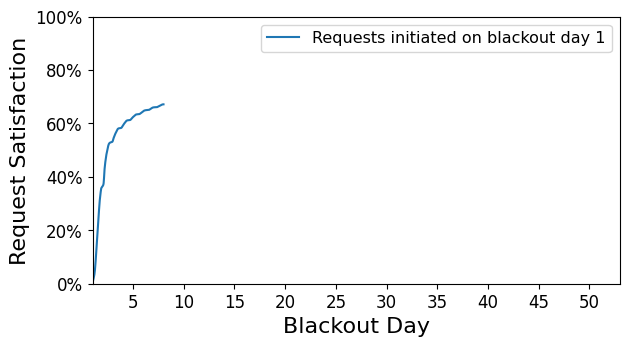

In [13]:
from matplotlib.ticker import PercentFormatter, MultipleLocator
plt.figure(figsize=(6.18, 3.358), constrained_layout=True)
markers = ['', 'o', '^', 's', 'P', 'D', 'x']
markevery=48
plt.plot(
    np.linspace(
        1,
        len(config.POSTBLACKOUT_DAYS),
        (len(config.POSTBLACKOUT_DAYS)) * 48,
    ),
    np.cumsum(satisfied_by_time[0][0 * 48 :]) / initiated_on_day[0],
    label=f"Requests initiated on blackout day {0+1}",
    marker=markers[0],
    #markevery= (i * (markevery // (num_initiating_days - 1)), markevery),

)
print(config.POW_LIMIT)
print((np.cumsum(satisfied_by_time[0][0 * 48 :]) / initiated_on_day[0])[-1])
'''
for i in range(num_initiating_days):
    plt.plot(
        np.linspace(
            i+1,
            len(config.POSTBLACKOUT_DAYS),
            (len(config.POSTBLACKOUT_DAYS) - i) * 48,
        ),
        np.cumsum(satisfied_by_time[i][i * 48 :]) / initiated_on_day[i],
        label=f"Requests initiated on blackout day {i+1}",
        marker=markers[i],
        markevery= (i * (markevery // (num_initiating_days - 1)), markevery),

    )
    print((np.cumsum(satisfied_by_time[i][i * 48 :]) / initiated_on_day[i])[-1])
'''
ax = plt.gca()
ax.set_xlim([1, 53])
ax.set_ylim([0, 1])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%
plt.gca().xaxis.set_major_locator(MultipleLocator(5))

plt.xlabel("Blackout Day", fontsize=16)
plt.ylabel("Request Satisfaction", fontsize=16)
plt.legend(prop={"size": 11.5})
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.savefig(f"plots/{the_run}/request-satisfaction-curve.pdf", format="pdf")


In [66]:
# Latency

groupings = [[], [], [], [], [], []]

include_unsatisfied = False

for user in users:
    for request in user.requested_pages:
        grouping_index = 0
        if request.index >= 10 and request.index <= 99:
            grouping_index = 1
        elif request.index >= 100 and request.index <= 999:
            grouping_index = 2
        elif request.index >= 1000 and request.index <= 9999:
            grouping_index = 3
        elif request.index >= 10000 and request.index <= 99999:
            grouping_index = 4
        elif request.index >= 100000:
            grouping_index = 5

        if request.is_resolved():
            groupings[grouping_index].append(
                ((request.resolved_days[0] - request.started_day) * 48
                + (request.resolved_timesteps[0] - request.started_timestep))/48
            )
        elif include_unsatisfied:
            groupings[grouping_index].append(
                
                ((config.POSTBLACKOUT_DAYS[-1] - request.started_day) * 48
                + (48 - request.started_timestep))/48
            )

6.020833333333333


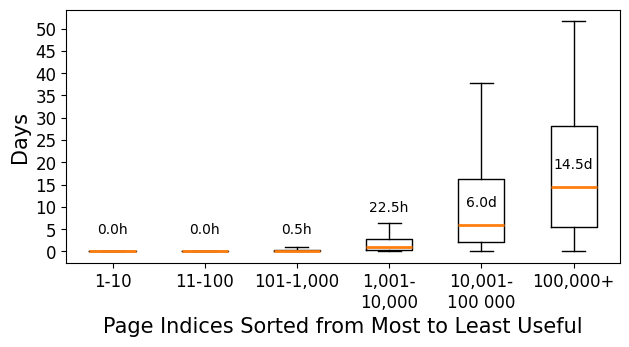

In [67]:
import matplotlib.ticker as ticker

zeroth = np.array(groupings[4])
print(np.percentile(zeroth, 50))
plt.figure(figsize=(6.18, 3.358), constrained_layout=True)
bp = plt.boxplot(groupings, positions=[1, 2, 3, 4, 5, 6], showfliers = False)
for median in bp['medians']:
    median.set(linewidth=2)
plt.xticks([1, 2, 3, 4, 5, 6], ['1-10', '11-100', '101-1,000', '1,001-\n10,000', '10,001-\n100 000', '100,000+'])
offsets = [4, 4, 4, 8, 4, 4]
for index, grouping in enumerate(groupings):
    original_median = np.percentile(np.array(grouping), 50)
    median = original_median
    suffix = 'd'
    if (median < 1):
        median *= 24
        suffix = 'h'
        
    median = round(median, 1)
    plt.text(index + 1, original_median + offsets[index], f'{median}{suffix}', horizontalalignment='center')

plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Days', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="15")
plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5))
ax = plt.gca()
extra_string = "unsatisfied" if include_unsatisfied else "satisfied"
plt.savefig(f"plots/{the_run}/box-whisker-{extra_string}.pdf", format="pdf")
plt.show()

In [68]:
grouping_percents = np.array([0, 0, 0, 0, 0, 0])
grouping_totals = np.array([0, 0, 0, 0, 0, 0])

for user in users:
    for request in user.requested_pages:
        grouping_index = 0
        if request.index >= 10 and request.index <= 99:
            grouping_index = 1
        elif request.index >= 100 and request.index <= 999:
            grouping_index = 2
        elif request.index >= 1000 and request.index <= 9999:
            grouping_index = 3
        elif request.index >= 10000 and request.index <= 99999:
            grouping_index = 4
        elif request.index >= 100000:
            grouping_index = 5
        
        grouping_totals[grouping_index] += 1
        if request.is_resolved():
            grouping_percents[grouping_index] += 1

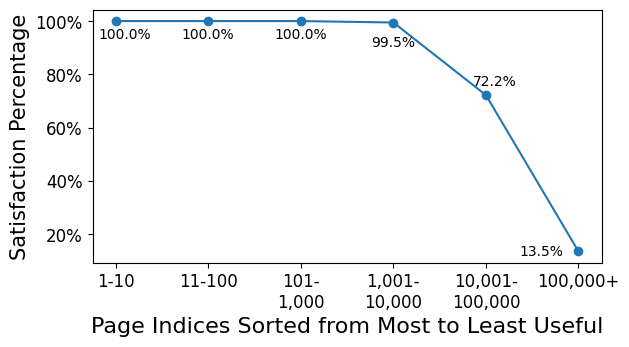

In [69]:
plt.figure(figsize=(6.18, 3.358), constrained_layout=True)
x = [0, 1, 2, 3, 4, 5]
y = grouping_percents / grouping_totals
plt.plot(x, y, marker='o')

plt.xticks([0, 1, 2, 3, 4, 5], ['1-10', '11-100', '101-\n1,000', '1,001-\n10,000', '10,001-\n100,000', '100,000+'])
plt.tick_params(axis="both", which="major", labelsize=12)
plt.tick_params(axis="both", which="minor", labelsize=10)
plt.ylabel('Satisfaction Percentage', fontsize="15")
plt.xlabel("Page Indices Sorted from Most to Least Useful", fontsize="16")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))  # 1.0 means 100%


offsets = [(0.1, -0.05), (0, -0.05), (0, -0.05), (0, -0.075), (0.1, 0.05), (-0.4, 0)]
rounded_y = np.round(y, 3)
for i in range(6):
    xi = x[i]
    yi = rounded_y[i]
    plt.text(xi + offsets[i][0], yi + offsets[i][1], f"{yi*100}%", ha='center', va='center')

plt.savefig(f"plots/{the_run}/satisfaction-by-index.pdf", format="pdf")
plt.show()

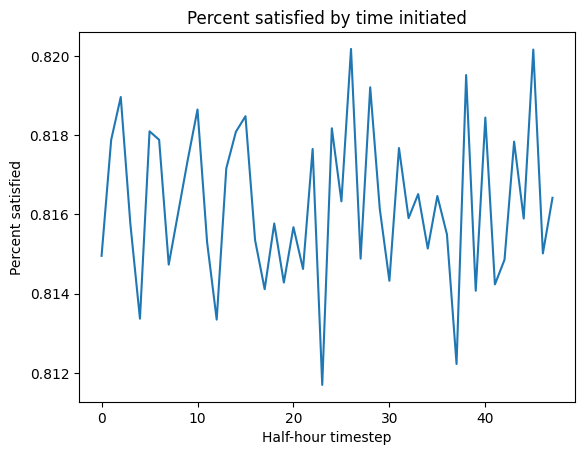

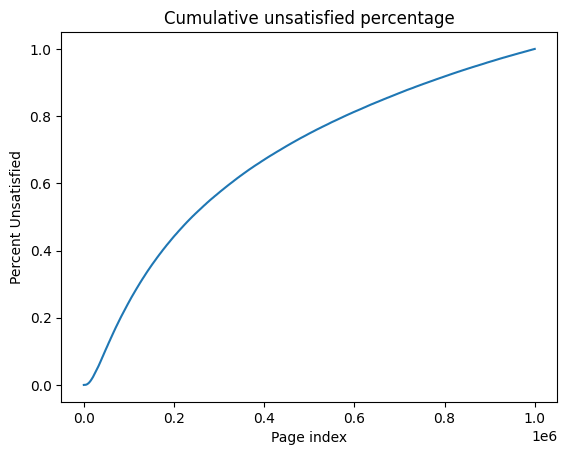

In [55]:


plt.figure()
plt.title("Percent satisfied by time initiated")
plt.plot(np.arange(0, 48), percent_satisfied_by_time_initiated)
plt.xlabel("Half-hour timestep")
plt.ylabel("Percent satisfied")
plt.savefig("percent_satisfied_by_time_initiated.png")

plt.figure()
plt.title("Cumulative unsatisfied percentage")
plt.plot(
    np.arange(0, config.PAGE_COUNT), np.cumsum(unsatisfied_by_index) / total_unsatisfied
)
plt.ylabel("Percent Unsatisfied")
plt.xlabel("Page index")
plt.savefig("cumulative_unsatisfied_percentage.png")
plt.show()

In [ ]:
plt.title(
    f"regular={config.NUM_REGULAR/config.TOTAL_USERS}, adversary = {config.NUM_ADVERSARY/config.TOTAL_USERS}, multiplier = {config.ADVERSARY_FORCE_MULTIPLIER}"
)
plt.ylabel("Ranking")
plt.xlabel("Page Index")
plt.plot(
    np.arange(0, config.PAGE_COUNT), average_leech_probabilities.toarray().flatten()
)
plt.savefig(f"plots/{the_run}/average_leech_probs.png")

plt.figure()
plt.title("Cumulative Distribution")
zipf = ranking_to_zipf(average_leech_probabilities.toarray().flatten())
zipf /= np.sum(zipf)
plt.plot(np.arange(0, config.PAGE_COUNT), np.cumsum(zipf))
plt.savefig(f"plots/{the_run}/leech_probs_cumulative_dist.png")